### Demonstration of ROI determination with stardist

In [1]:
import sys
sys.path.insert(0, '..')

import roiadjust as ra
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
import numpy as np

import zipfile
from roifile import ImagejRoi

##### First, determine a path to a folder containing at least one video or to a file itself.

In [2]:
# Auto-Reload of .py files
%reload_ext autoreload

# Load video either as a specified file or as a set of files in a directory
path_orig = "K+_1.avi" # path to video file or directory
video, video_path = ra.load_file(path_orig, multi_files=True, file_id=1) # Load video

# FPS of the videos
video_fps = 5 

Lenght of video: 2500 Frames


##### Next, we create the mean intensity image of the video that is needed for the prediction of cells.

In [3]:
# Mean intensity of the video along axis 0 (frames)
video_mean = video.mean(axis=0)

##### The ROIs are next predicted using stardists pretrained model forfFluorescence stainings which takes 2D single channel pictures

In [4]:
# Predict ROIs using the video, with a probability threshold of "prob"
labels, polygons = ra.predict_neurons(video_mean, video_path, export=False, prob=0.7)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


##### Next, the predicted ROIs are scanned for activity. Active ROIs are assigned to the positive_rois.

In [5]:
# Analyze the ROI traces using the video, with a prominence of "prom" and a cutoff of "cutoff"
positive_rois = ra.analyze_roi_traces(video, video_mean, video_path, labels, video_fps, 
                                      show_graphs=False, prom=6, cutoff=0.2)

17 counted, positive ROIs


##### The positive ROIs can then be exported as ImageJ compatible format in .zip file.

In [6]:
# Create the selected ROIs as ImageJ ROIs, with the option to export as .zip files
polygons_positive = ra.export_roi_selection(selected_rois=positive_rois, 
    polygons=polygons, export=True, roi_output="demo_rois.zip")

Exported selected ROIs to: demo_rois.zip


##### The whole pipeline can also be ran in one command.

Lenght of video: 2500 Frames
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
12 counted, positive ROIs
Selected ROIs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13]


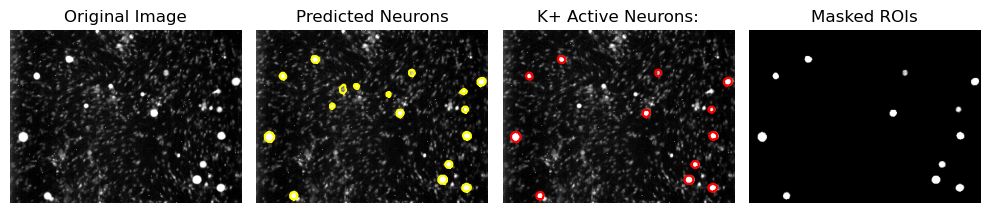

In [7]:
# Or run the whole pipeline in one step, which will load the video, 
# predict ROIs, analyze the traces and export the selected ROIs as ImageJ ROIs in one step. 
# The parameters can be adjusted as needed.
# compare=True will show the predicted ROIs on the video mean and the selected ROIs 
# on the video mean next to each other for comparison.
ra.roi_pipeline(path="K+_1.avi", roi_output="demo_rois.zip",
                export=False, prob=0.7, video_fps=5, 
                show_graphs=False, prom=10, cutoff=0.1, compare=True)

### Usage of ROIs with motion aligned videos

##### Again, we will first load the motion corrected video that is used for the prediction of ROIs. Then we will load the motion aligned video that should be analyzed with the ROIs.

In [8]:
# Loading of the videos either as a specified file or as a set of files in a directory
path_corr_k= "K+_1_corrected.avi" # path to video file or directory
video_corr_k, video_path_corr_k = ra.load_file(path_corr_k) # Load video

path_al_spon = "spontan_1_aligned.avi" 
video_al_spon, video_path_al_spon = ra.load_file(path_al_spon)

# define the FPS of the videos
video_fps = 5 

Lenght of video: 1501 Frames
Lenght of video: 2500 Frames


##### To run further analyses and to be able to plot the ROIs, we will need the mean intensity images.

In [9]:
# Mean intensity of the video along axis 0 (frames)
video_corr_k_mean = video_corr_k.mean(axis=0)
video_al_spon_mean = video_al_spon.mean(axis=0)

##### Next we will run the prediction on the motion corrected video.

In [11]:
# Predict ROIs using the video, with a probability threshold of "prob"
labels_corr_k, polygons_corr_k = ra.predict_neurons(video_corr_k_mean, video_path_corr_k, export=False, prob=0.7)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


##### Now we can plot the predicted ROIs on the mean image of the original and aligned video to see how well they match up.

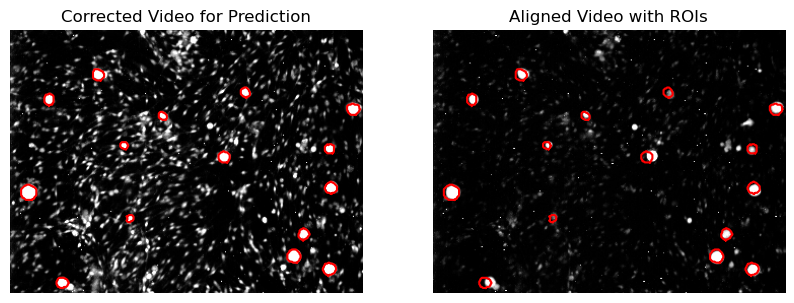

In [11]:
#plot video_al_spon_mean and _k_mean next to each other
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ra.plot_roi_contours(video_al_spon_mean, labels_corr_k, roi_ids=None, color="red", ax=axs[1])
axs[1].set_title("Aligned Video with ROIs")
ra.plot_roi_contours(video_corr_k_mean, labels_corr_k, roi_ids=None, color="red", ax=axs[0])
axs[0].set_title("Corrected Video for Prediction")
plt.show()

### Quality Control

##### Last, it is always a good idea to run a quality control to see if the motion adjustment worked the way it was planned. Because the whole scripts are run in a SnakeMake Environment we cannot access the predicted polygons directly, but have to load the exported .zip files as shown below.

In [12]:
# First, we access the .zip file and look for the .roi files in there
zip_path = "demo_rois_aligned.zip" # File path to .zip file
zip_roi = zipfile.ZipFile(zip_path, 'r') # open in read r mode
roi_files = [f for f in zip_roi.namelist()] # list the .roi files

print(roi_files)

['001_001.roi', '001_002.roi', '001_003.roi', '001_004.roi', '001_005.roi', '001_006.roi', '001_007.roi', '001_008.roi', '001_009.roi', '001_010.roi', '001_011.roi', '001_012.roi', '001_013.roi', '001_014.roi', '001_015.roi']


In [13]:
# Now we can run and load the .roi files
roi_bytes = zip_roi.read(roi_files[0]) # Read the .roi files as bytes
roi_object = ImagejRoi.frombytes(roi_bytes) # Read the bytes as ROI

In [14]:
# We can now access the data and coordinates of the ROI
print(roi_object.subpixel_coordinates)

[[345.66095   78.5     ]
 [345.27377   79.84739 ]
 [344.66043   81.05173 ]
 [343.918     82.12019 ]
 [342.8956    82.89561 ]
 [341.93478   83.64053 ]
 [340.6707    83.74046 ]
 [339.6329    84.19549 ]
 [338.5       84.36955 ]
 [337.39258   84.06736 ]
 [336.42578   83.507614]
 [335.34402   83.223236]
 [334.73013   82.26987 ]
 [333.76804   81.6618  ]
 [333.6398    80.51317 ]
 [332.98257   79.59748 ]
 [332.5223    78.5     ]
 [332.7189    77.35007 ]
 [333.23813   76.32046 ]
 [333.4026    75.09401 ]
 [334.45395   74.45395 ]
 [335.244     73.62705 ]
 [336.47037   73.60001 ]
 [337.42645   73.102875]
 [338.5       72.91749 ]
 [339.5904    73.01815 ]
 [340.5205    73.62207 ]
 [341.81662   73.53632 ]
 [342.82      74.179985]
 [344.12756   74.73978 ]
 [344.9261    75.838234]
 [345.42197   77.12314 ]]


##### To access more than one ROI we can run the script in a loop.

In [15]:
# We create a list to store the ROI coordinates, type and name/index
roi_data_list = []

# Loop through the ROI files
for i, roi_file in enumerate(roi_files):
    # Read ROI from the zip file
    roi_bytes = zip_roi.read(roi_file)
    print(f"Successfully extracted ROI file: {roi_file}")
    roi_object = ImagejRoi.frombytes(roi_bytes)
    
    # Saving ROI data
    roi_info = {
        'type': roi_object.roitype,
        'coordinates': roi_object.coordinates if hasattr(roi_object, 'coordinates') else None,
        'subpixel_coordinates': roi_object.subpixel_coordinates if hasattr(roi_object, 'subpixel_coordinates') else None,
        'name': roi_file,
        'index': i
    }

    # Append the ROI information to the list for potential further use
    roi_data_list.append(roi_info)

Successfully extracted ROI file: 001_001.roi
Successfully extracted ROI file: 001_002.roi
Successfully extracted ROI file: 001_003.roi
Successfully extracted ROI file: 001_004.roi
Successfully extracted ROI file: 001_005.roi
Successfully extracted ROI file: 001_006.roi
Successfully extracted ROI file: 001_007.roi
Successfully extracted ROI file: 001_008.roi
Successfully extracted ROI file: 001_009.roi
Successfully extracted ROI file: 001_010.roi
Successfully extracted ROI file: 001_011.roi
Successfully extracted ROI file: 001_012.roi
Successfully extracted ROI file: 001_013.roi
Successfully extracted ROI file: 001_014.roi
Successfully extracted ROI file: 001_015.roi


In [16]:
# We can now access individual ROIs and their coordinates
print(roi_data_list[0]["subpixel_coordinates"])

[[345.66095   78.5     ]
 [345.27377   79.84739 ]
 [344.66043   81.05173 ]
 [343.918     82.12019 ]
 [342.8956    82.89561 ]
 [341.93478   83.64053 ]
 [340.6707    83.74046 ]
 [339.6329    84.19549 ]
 [338.5       84.36955 ]
 [337.39258   84.06736 ]
 [336.42578   83.507614]
 [335.34402   83.223236]
 [334.73013   82.26987 ]
 [333.76804   81.6618  ]
 [333.6398    80.51317 ]
 [332.98257   79.59748 ]
 [332.5223    78.5     ]
 [332.7189    77.35007 ]
 [333.23813   76.32046 ]
 [333.4026    75.09401 ]
 [334.45395   74.45395 ]
 [335.244     73.62705 ]
 [336.47037   73.60001 ]
 [337.42645   73.102875]
 [338.5       72.91749 ]
 [339.5904    73.01815 ]
 [340.5205    73.62207 ]
 [341.81662   73.53632 ]
 [342.82      74.179985]
 [344.12756   74.73978 ]
 [344.9261    75.838234]
 [345.42197   77.12314 ]]


##### The List of multiple ROIs can be plotted on a mean intensity image

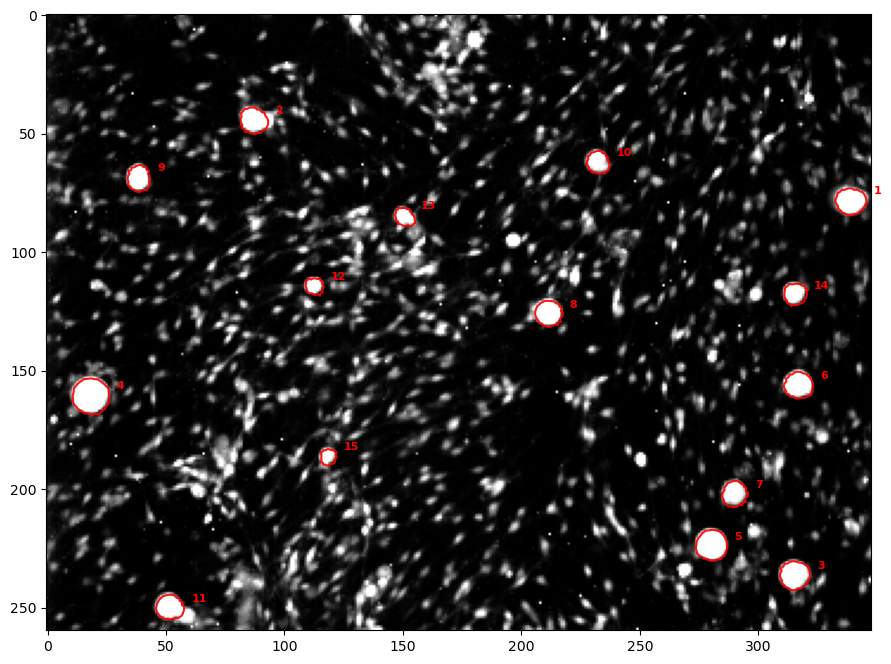

In [18]:
# Now these ROIs can be read an plotted on an mean intensity image
fig, ax = plt.subplots(figsize=(12, 8)) # create the plot
ax.imshow(video_corr_k_mean, cmap="gray", vmax=20) # load mean intensity image

for i, roi in enumerate(roi_data_list):
    # Format coords
    coords = None
    if roi["subpixel_coordinates"] is not None:
        coords = roi["subpixel_coordinates"]
    elif roi['coordinates'] is not None:
        coords = roi["coordinates"]

    # Print ROIs as polygons
    if coords is not None:
        poly = Polygon(coords, closed=True, fill=False, edgecolor="red", linewidth=1.5, alpha=0.9)
        ax.add_patch(poly)
        ax.text(coords[0][0] + 3, coords[0][1] - 3, str(i + 1), 
            color="red", fontsize=8, weight='bold')

plt.show()

##### The whole process can also be called by defined functions

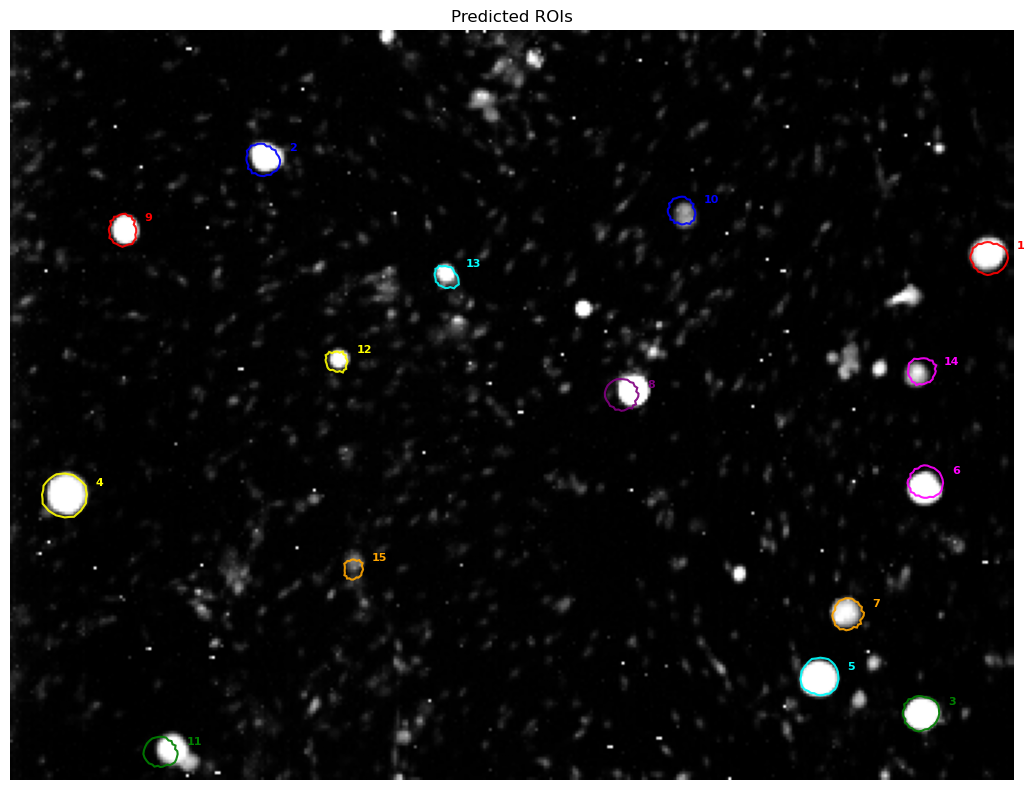

In [20]:
# To open, read and extract ROI data from .zip archives
roi_data_list = ra.load_rois_from_zip("demo_rois_aligned.zip", video_al_spon_mean, plot=True)

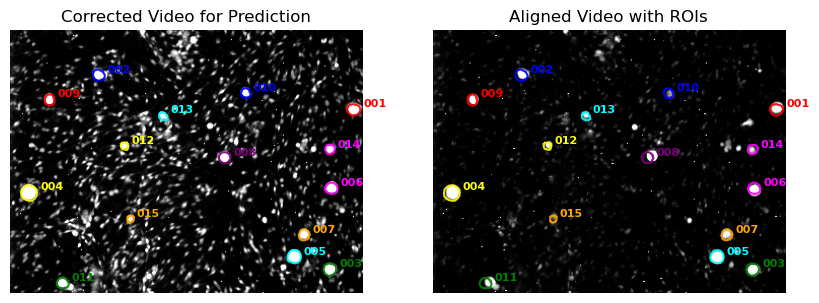

In [21]:
# To plot and compare between two conditions
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ra.plot_rois(video_corr_k_mean, roi_data_list, ax=axs[0])
axs[0].set_title("Corrected Video for Prediction")
ra.plot_rois(video_al_spon_mean, roi_data_list, ax=axs[1])
axs[1].set_title("Aligned Video with ROIs")
plt.show()

Lenght of video: 2500 Frames
Lenght of video: 1501 Frames


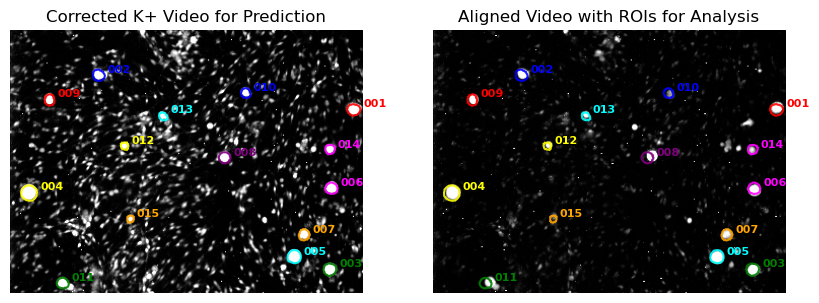

In [23]:
# Or to run the whole pipeline in one command
ra.roi_qc(zip_path="demo_rois_aligned.zip",potassium_vid_path="K+_1_corrected.avi",
          spon_vid_path="spontan_1_aligned.avi")